# Moravec detector

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
plt.rcParams['image.cmap'] = 'gray'

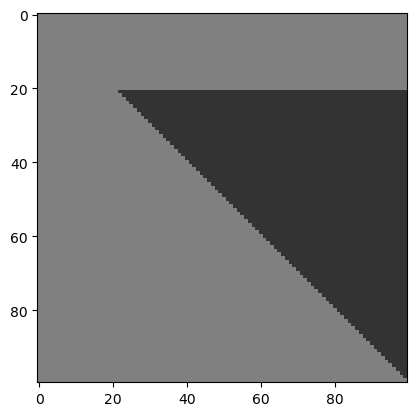

In [2]:
# Image
N = 100
m, n = np.meshgrid(range(N), range(N))
img = np.where( (n>20) * (n-m<0), .2, .5)
plt.imshow(img, vmin=0, vmax=1)

In [3]:
def case(num, img, center):
    """Affichage d'un cas particulier
    num : numéro du cas (0 à 2)
    img : image
    center : origine de la première imagette
    """

    # Taille des imagettes
    s = 20

    # Couleurs des imagettes
    colors = ['#f00', '#0f0', '#0ff']

    # Coordonnées des imagettes
    coords = [
        [center[0],   center[1]],
        [center[0]+1, center[1]+6],
        [center[0]+6, center[1]+1]]

    # Affichage de l'image
    ax_top[num].imshow(img, vmin=0, vmax=1)

    # Traitement de chaque imagette
    for k in range(len(coords)):

        # Coordonnées de l'imagette
        y, x = coords[k]

        # Rectangle de couleur sur l'image
        rect = plt.Rectangle((x, y), s, s, edgecolor=colors[k], fill=False)
        ax_top[num].add_patch(rect)
        
        # Crop de l'imagette
        sub = img[y:y+s, x:x+s]

        # Affichage de l'imagette et du cadre
        ax = ax_bottom[3*num + k]
        ax.imshow(sub, vmin=0, vmax=1)
        for axis in ['top','bottom','left','right']:
            ax.spines[axis].set_color(colors[k])
            ax.spines[axis].set_linewidth(1.5)


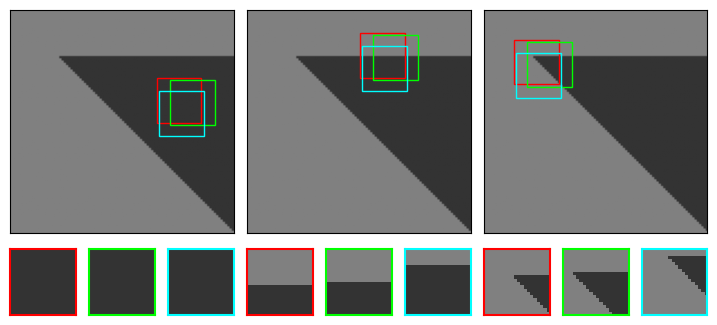

In [4]:
# Figure
fig = plt.figure(figsize=(9, 4))

# Configuration du GridSpec : 4 lignes, 9 colonnes
space = .2
gs = gridspec.GridSpec(4, 9, figure=fig, wspace=space, hspace=space)

# Initialisation des axes
ax_top = [
    fig.add_subplot(gs[0:3, 0:3]),
    fig.add_subplot(gs[0:3, 3:6]),
    fig.add_subplot(gs[0:3, 6:9]),
]
ax_bottom = [fig.add_subplot(gs[3, i]) for i in range(9)]

# Cas
case(0, img, [30, 65])  # Flat
case(1, img, [10, 50])  # Edge
case(2, img, [13, 13])  # Corner

# Ratio carré et pas de labels
for ax in ax_top + ax_bottom:
    ax.set_box_aspect(1)
    ax.set_xticks([])
    ax.set_yticks([])

# Enregistrement et affichage
plt.savefig('corners-moravec.svg', bbox_inches='tight')
plt.show()